Total labeled corner-instances: 42573
Races included: ['Belgian Grand Prix' 'Monza' 'Silverstone']
Drivers included: 21
Corners per race: race
Belgian Grand Prix    19
Monza                 11
Silverstone           18
Name: corner_number, dtype: int64


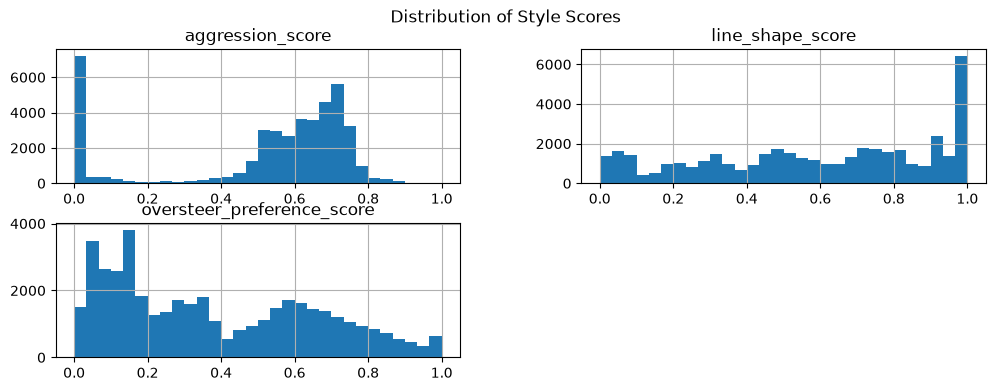

       aggression_score  line_shape_score  oversteer_preference_score
count      42573.000000      42573.000000                42573.000000
mean           0.511170          0.590124                    0.380066
std            0.264099          0.310370                    0.274253
min            0.000000          0.000000                    0.000000
25%            0.481144          0.329780                    0.134708
50%            0.610850          0.626478                    0.321470
75%            0.699525          0.884484                    0.612441
max            1.000000          1.000000                    1.000000
driver
10    0.674063
43    0.635576
77    0.625001
11    0.624604
63    0.609663
27    0.602169
16    0.600306
23    0.595506
3     0.593090
22    0.586676
55    0.580746
44    0.578017
14    0.575665
4     0.575065
20    0.573336
31    0.568972
24    0.559494
81    0.556434
18    0.546928
1     0.537952
2     0.535011
Name: aggression_score, dtype: float64
session_t

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

labels = pd.read_parquet('../fastf1_data/labeled/labels_combined.parquet')

# 1. Basic shape of the dataset
print(f"Total labeled corner-instances: {labels.shape[0]}")
print(f"Races included: {labels['race'].unique()}")
print(f"Drivers included: {labels['driver'].nunique()}")
print(f"Corners per race: {labels.groupby('race')['corner_number'].nunique()}")

# 2. Distribution of the three target scores — the "do these scores actually vary" check
labels[['aggression_score', 'line_shape_score', 'oversteer_preference_score']].hist(figsize=(12, 4), bins=30)
plt.suptitle('Distribution of Style Scores')
plt.show()

# 3. Summary stats
print(labels[['aggression_score', 'line_shape_score', 'oversteer_preference_score']].describe())

# 4. Driver comparison (Turn 1, the check we already did)
turn_1 = labels[labels['corner_number'] == 1]
print(turn_1.groupby('driver')['aggression_score'].mean().sort_values(ascending=False))

# 5. Session type balance (Qualifying vs Race row counts)
print(labels['session_type'].value_counts())

In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
import joblib
import glob

# 1. Load labels + the raw sliced telemetry (need raw for feature stats)
labels = pd.read_parquet('../fastf1_data/labeled/labels_combined.parquet')
segmented_files = glob.glob('../fastf1_data/processed/corners_*.parquet')
segmented = pd.concat([pd.read_parquet(f) for f in segmented_files], ignore_index=True)

# 2. Build flat features — ONLY raw, unsmoothed columns (leakage prevention:
#    Throttle_smooth/Brake_smooth/Speed_smooth were used to CALCULATE the
#    labels, so they cannot be used as model inputs)
SAFE_COLUMNS = ['Throttle', 'Brake', 'Speed', 'nGear', 'RPM']

feature_rows = []
for (year, race, session_type, driver, lap_num, corner_num), group in segmented.groupby(
    ['year', 'race', 'session_type', 'driver', 'lap_number', 'corner_number']
):
    row = {'year': year, 'race': race, 'session_type': session_type,
           'driver': driver, 'lap_number': lap_num, 'corner_number': corner_num}
    for col in SAFE_COLUMNS:
        row[f'{col}_mean'] = group[col].mean()
        row[f'{col}_std'] = group[col].std()
        row[f'{col}_min'] = group[col].min()
        row[f'{col}_max'] = group[col].max()
    feature_rows.append(row)

features_df = pd.DataFrame(feature_rows)

# 3. Merge with labels (only keep rows that survived the out-lap filter in labeling)
data = features_df.merge(
    labels[['year', 'race', 'session_type', 'driver', 'lap_number', 'corner_number',
            'aggression_score', 'line_shape_score', 'oversteer_preference_score']],
    on=['year', 'race', 'session_type', 'driver', 'lap_number', 'corner_number']
)
data = data.dropna()
print(f"Final dataset: {data.shape}")

# 4. Split by DRIVER (not randomly) — prevents the model from
#    seeing the same driver's data in both train and validation
splitter = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)
train_idx, val_idx = next(splitter.split(data, groups=data['driver']))
train_df, val_df = data.iloc[train_idx], data.iloc[val_idx]

feature_cols = [c for c in data.columns if c.endswith(('_mean', '_std', '_min', '_max'))]
target_cols = ['aggression_score', 'line_shape_score', 'oversteer_preference_score']

# 5. Scale (fit on train only)
scaler = StandardScaler()
train_df = train_df.copy()
val_df = val_df.copy()
train_df[feature_cols] = scaler.fit_transform(train_df[feature_cols])
val_df[feature_cols] = scaler.transform(val_df[feature_cols])

# 6. Save everything models will need
train_df.to_parquet('../fastf1_data/labeled/train_data.parquet')
val_df.to_parquet('../fastf1_data/labeled/val_data.parquet')
joblib.dump(scaler, '../models/scaler.pkl')

print(f"Train: {train_df.shape}, Val: {val_df.shape}")
print(f"Feature columns: {feature_cols}")

Final dataset: (42573, 29)
Train: (33592, 29), Val: (8981, 29)
Feature columns: ['Throttle_mean', 'Throttle_std', 'Throttle_min', 'Throttle_max', 'Brake_mean', 'Brake_std', 'Brake_min', 'Brake_max', 'Speed_mean', 'Speed_std', 'Speed_min', 'Speed_max', 'nGear_mean', 'nGear_std', 'nGear_min', 'nGear_max', 'RPM_mean', 'RPM_std', 'RPM_min', 'RPM_max']
